In [ ]:
print("Hello, neurons.")

Hello, neurons.


In [ ]:
import numpy as np

# Create a NumPy array from 1 to 20 (inclusive) using np.arange
# Note: np.arange stops before the second argument, so we use 21.
numbers = np.arange(1, 21)

# Calculate and print the mean of the array using np.mean()
mean_value = np.mean(numbers)
print(f"Mean: {mean_value}")

# Calculate and print the standard deviation of the array using np.std()
std_value = np.std(numbers)
print(f"Standard Deviation: {std_value:.4f}")

# Find even numbers using the modulo operator (numbers % 2 == 0) as a mask,
# then calculate the sum of those even numbers using np.sum()
sum_of_evens = np.sum(numbers[numbers % 2 == 0])
print(f"Sum of even numbers: {sum_of_evens}")


Mean: 10.5
Standard Deviation: 5.7663
Sum of even numbers: 110


In [ ]:
import numpy as np

def relu(x):
    # np.maximum() compares every element in the array 'x' with 0.
    # If the element is greater than 0, it keeps the element's value.
    # If the element is 0 or less, it replaces it with 0.
    return np.maximum(0, x)

# Create the NumPy array with the given values
input_array = np.array([-3, -1, 0, 1, 3, 5])

# Apply the relu function to the input array
output_array = relu(input_array)

# Print the original and the modified arrays to see the difference
print(f"Input array:  {input_array}")
print(f"Output array: {output_array}")


Input array:  [-3 -1  0  1  3  5]
Output array: [0 0 0 1 3 5]


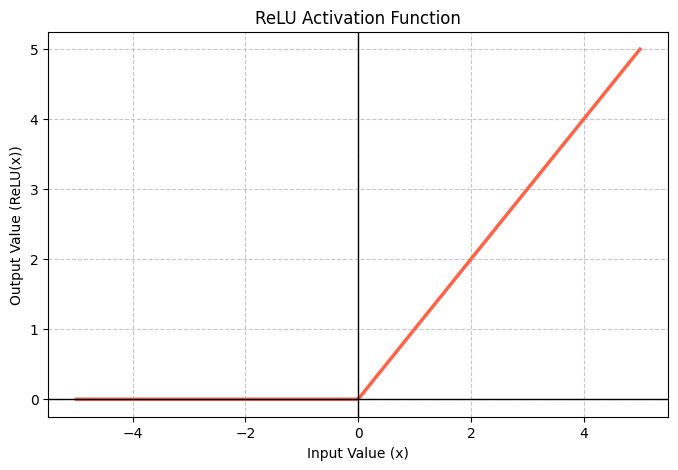

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# We reuse the relu function defined in the previous exercise
def relu(x):
    return np.maximum(0, x)

# Generate an array of evenly spaced x values from -5 to 5.
# np.linspace(-5, 5, 200) creates 200 points to make the line smooth.
x_values = np.linspace(-5, 5, 200)

# Calculate the corresponding y values by applying the relu function
y_values = relu(x_values)

# Create a figure for the plot
plt.figure(figsize=(8, 5))

# Plot the x and y values. We use a clear color and a slightly thicker line.
plt.plot(x_values, y_values, color='tomato', linewidth=2.5)

# Add a title to the plot
plt.title('ReLU Activation Function')

# Add labels for the X and Y axes
plt.xlabel('Input Value (x)')
plt.ylabel('Output Value (ReLU(x))')

# Add a grid to make it easier to read the values
plt.grid(True, linestyle='--', alpha=0.7)

# Draw horizontal and vertical lines at 0 for better reference against axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Display the final plot
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset from scikit-learn
iris = load_iris()

# Create a DataFrame for easier data manipulation
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
# Map the numeric targets to their actual string names (0: setosa, 1: versicolor, 2: virginica)
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Group the data by species and calculate the min, max, mean, and std for 'petal length (cm)'
petal_stats = df.groupby('species_name')['petal length (cm)'].agg(['min', 'max', 'mean', 'std'])

# Print the calculated statistics for each species
print("Petal Length Statistics per Species:")
print(petal_stats)

# Find the species with the most consistent petal length (lowest standard deviation)
# .idxmin() returns the index (species name) of the minimum value in the 'std' column
most_consistent = petal_stats['std'].idxmin()

print(f"\nThe species with the most consistent petal length is: {most_consistent.capitalize()}")


Petal Length Statistics per Species:
              min  max   mean       std
species_name                           
setosa        1.0  1.9  1.462  0.173664
versicolor    3.0  5.1  4.260  0.469911
virginica     4.5  6.9  5.552  0.551895

The species with the most consistent petal length is: Setosa


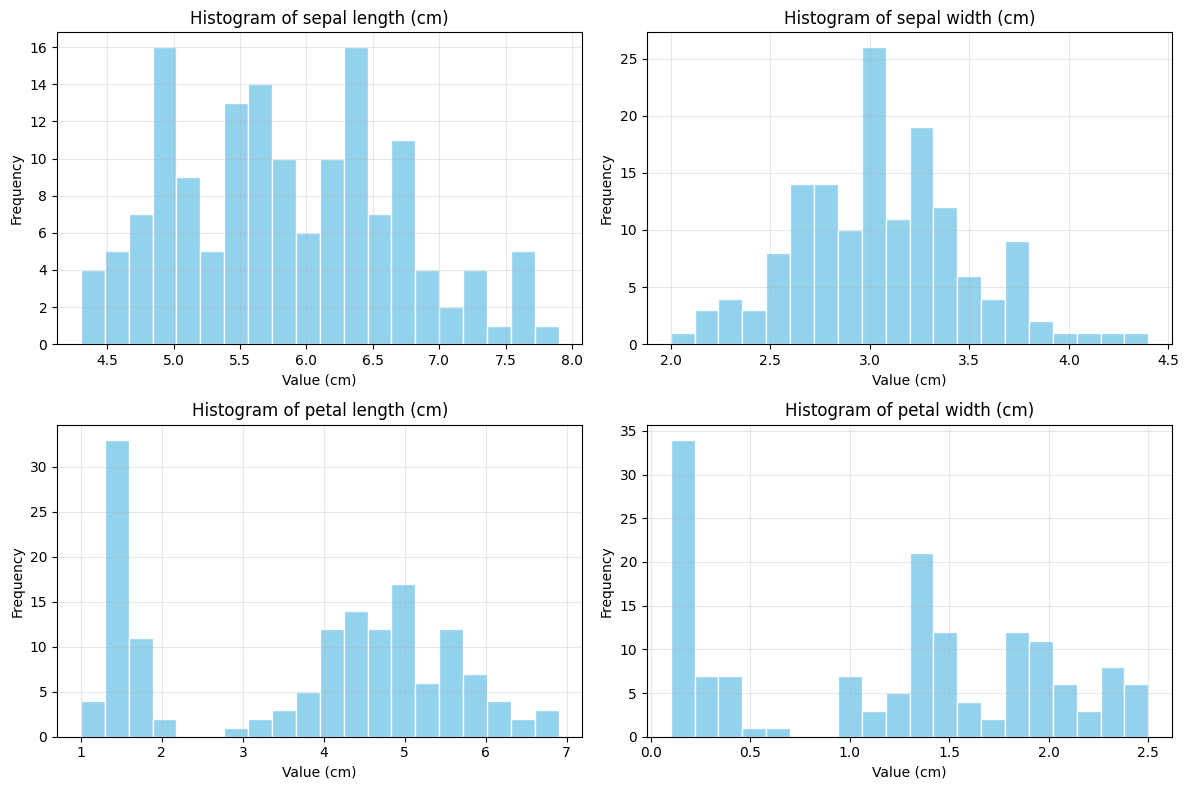

In [ ]:
import matplotlib.pyplot as plt

# Create a 2x2 grid of subplots with a specified figure size
# 'axes' is a 2D array of the subplot areas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Get the list of feature column names (first 4 columns in our dataframe)
feature_names = iris.feature_names

# Loop through the 4 features and their corresponding subplots
# axes.flatten() converts the 2x2 matrix into a 1D array for easier looping
for i, ax in enumerate(axes.flatten()):
    feature = feature_names[i]

    # Plot a histogram for the current feature
    ax.hist(df[feature], bins=20, color='skyblue', edgecolor='white', alpha=0.9)

    # Set the title and label
    ax.set_title(f'Histogram of {feature}')
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Adjust the layout so titles and labels don't overlap
plt.tight_layout()

# Display all subplots
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Extract the feature numerical values directly as a NumPy array
X = iris.data

# 1. Manual Normalization
# Axis=0 means compute the mean and std along the columns (features)
mean_vals = np.mean(X, axis=0)
std_vals = np.std(X, axis=0)

# Broadcast subtraction and division to scale all elements manually
X_manual_scaled = (X - mean_vals) / std_vals

# 2. Scikit-learn Normalization (for verification)
scaler = StandardScaler()
X_sklearn_scaled = scaler.fit_transform(X)

# 3. Verification
# np.allclose checks if two arrays are element-wise equal within a tolerance
is_same = np.allclose(X_manual_scaled, X_sklearn_scaled)

print(f"Are manual scaling and StandardScaler results the same? : {is_same}")

# Print the first row to visually see they match
print("\nFirst row manual:  ", X_manual_scaled[0])
print("First row sklearn: ", X_sklearn_scaled[0])

Are manual scaling and StandardScaler results the same? : True

First row manual:   [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
First row sklearn:  [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]


In [ ]:
# The sigmoid activation function (as explained in section 2.3)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Set a random seed so the results are reproducible when you run the cell multiple times
np.random.seed(42)

# Create a random weight matrix W of shape (5, 4) using standard normal distribution
W = np.random.randn(5, 4)

# Create a random input vector x of shape (4,)
x = np.random.randn(4)

# Compute the dot product.
# W(5x4) multiplied by x(4x1) results in an output of shape (5,)
dot_product = np.dot(W, x)

# Apply the sigmoid function element-wise across the dot product result array
output = sigmoid(dot_product)

# Print out the results and the final shape
print("Weight matrix W shape:", W.shape)
print("Input vector x shape:", x.shape)
print("Output before sigmoid:", dot_product)
print("Output after sigmoid: ", output)

# This is the answer to the question "What is the shape of the output?"
print("\nThe final shape of the output is:", output.shape)


Weight matrix W shape: (5, 4)
Input vector x shape: (4,)
Output before sigmoid: [-1.36697149 -1.27708386 -0.1783279   1.47124257  0.39545562]
Output after sigmoid:  [0.20310959 0.21804702 0.4555358  0.81324618 0.59759534]

The final shape of the output is: (5,)


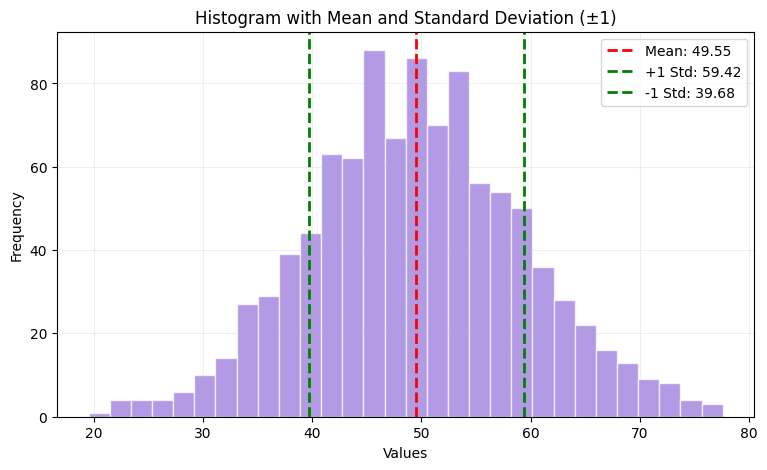

In [ ]:
def plot_hist_with_stats(data_array):
    """
    Plots a histogram of the provided numpy array and adds vertical lines
    representing the mean, and the mean ± 1 standard deviation.
    """

    # Calculate required statistics
    mean_val = np.mean(data_array)
    std_val = np.std(data_array)

    # Initialize the plot area
    plt.figure(figsize=(9, 5))

    # Plot the histogram
    # Using density=False to show plain counts, with semi-transparent color
    plt.hist(data_array, bins=30, color='mediumpurple', edgecolor='white', alpha=0.7)

    # Plot the Mean (Red dashed line)
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2,
                label=f'Mean: {mean_val:.2f}')

    # Plot Mean + 1 Std and Mean - 1 Std (Green dashed lines)
    plt.axvline(mean_val + std_val, color='green', linestyle='--', linewidth=2,
                label=f'+1 Std: {mean_val + std_val:.2f}')
    plt.axvline(mean_val - std_val, color='green', linestyle='--', linewidth=2,
                label=f'-1 Std: {mean_val - std_val:.2f}')

    # Add title, labels and a legend to clarify what the lines mean
    plt.title('Histogram with Mean and Standard Deviation (±1)')
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.2)

    # Show the plot
    plt.show()


# TEST THE FUNCTION
# Generate 1000 random data points from a normal distribution.
# (e.g., Target mean = 50, Target std = 10)
np.random.seed(0)
test_data = np.random.normal(loc=50, scale=10, size=1000)

# Call our custom function
plot_hist_with_stats(test_data)


**What was the most confusing thing in this lab? Be specific.**

The most confusing part for me was understanding how matrix dimensions work during the dot product operations in Exercise 7. Visualizing what happens when a (5, 4) matrix is multiplied by a (4,) vector took me some time to grasp. Also, grasping the concept of "broadcasting" in NumPy, like when we subtracted the mean from the entire feature matrix at once during manual data scaling, felt a bit unintuitive at first. However, printing out the shapes (.shape) at each step really helped me figure it out.

**What does the dot product in section 3.6 have to do with a neuron? Explain it in your own words.**

A biological neuron receives multiple signals, gives different importance to each signal, and then sums them up to decide whether to activate or not. In our code, the dot product does exactly this mathematical process: it multiplies every single incoming feature (input) by its corresponding importance measure (weight) and adds all of these products together into a single number. So basically, computing a dot product is just an efficient, mathematical way of calculating a neuron's total incoming stimulation before passing it to an activation function like the sigmoid.

**Why do we split data into training and test sets? What could go wrong if we didn't?**

We split the data because we need a way to prove that our neural network has actually learned the underlying patterns rather than just memorizing the examples we showed it. The test set acts as an "unseen final exam" to evaluate the model's true, real-world performance. If we evaluated the model using the exact same data it trained on, it would be like giving a student the answer key before a test; it would score 100% easily but fail miserably when faced with a slightly different, new problem (a problem known as "overfitting").